# 01 · Fonte e Qualidade dos Dados

Este projeto usa o iFood Data Business Analyst Test. É o case de dados que o próprio time iFood Brain publica em `github.com/ifood/ifood-data-business-analyst-test` para avaliar candidatos a Analista de Dados. O dataset descreve clientes que participaram de campanhas de marketing e diz se cada um aceitou ou não a oferta.

Nota de transparência: o dataset original trata de resposta de clientes a campanhas promocionais de compra de comida. Não é o Programa Super de fidelização de entregadores, e não existe dado público sobre esse programa específico. O que este projeto demonstra é a metodologia. Segmentação, teste de hipótese com desenho de grupo controle, modelo de propensão, monitoramento de KPI e dashboard, tudo aplicado a um problema de incentivo e engajamento estruturalmente parecido, usando dado real e publicamente rastreável da própria empresa.

## Guia de leitura

Cada notebook documenta uma decisão, o teste que a sustenta e a limitação registrada junto com o resultado.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = PROJECT_ROOT / "data"
REPORTS = PROJECT_ROOT / "reports"

sns.set_theme(style="whitegrid")
CORAL = "#F08FA0"
TEAL = "#0E6268"
DARK = "#15262B"

df = pd.read_csv(DATA / "ifood_df.csv")
df.shape

(2205, 39)

## 1. Origem e dicionário de dados

O arquivo `ifood_df.csv` já vem pré-processado pelos autores, com variáveis categóricas em one-hot e idade já calculada. O arquivo irmão `ml_project1_data.csv` traz a versão bruta, com `Education`, `Marital_Status` e `Dt_Customer` ainda em texto. Ele entra aqui só para conferência cruzada, não para a análise principal.

In [2]:
schema = pd.DataFrame({"tipo": df.dtypes.astype(str), "faltantes": df.isna().sum(), "valores_unicos": df.nunique()})
schema.head(15)

,tipo,faltantes,valores_unicos
Income,float64,0,1963
Kidhome,int64,0,3
Teenhome,int64,0,3
Recency,int64,0,100
MntWines,int64,0,775
MntFruits,int64,0,158
MntMeatProducts,int64,0,551
MntFishProducts,int64,0,182
MntSweetProducts,int64,0,176
MntGoldProds,int64,0,212


| Campo | Significado |
|---|---|
| `Income` | Renda anual declarada do cliente |
| `Recency` | Dias desde a última compra |
| `NumWebPurchases`, `NumCatalogPurchases`, `NumStorePurchases`, `NumDealsPurchases` | Compras por canal |
| `MntWines`, `MntFruits`, `MntMeatProducts`, `MntFishProducts`, `MntSweetProducts`, `MntGoldProds` | Valor gasto por categoria de produto |
| `AcceptedCmp1` a `AcceptedCmp5` | Aceitou a campanha promocional N; 1 significa sim |
| `Response` | Aceitou a campanha mais recente; essa é a variável-alvo |
| `Complain` | Registrou reclamação nos últimos 2 anos |
| `Age`, `Customer_Days` | Idade e tempo de relacionamento com a empresa |

Para dar significado de negócio ao vocabulário da vaga, três variáveis derivadas são criadas e usadas em todos os notebooks seguintes:

- `frequencia_total` soma todas as compras por canal e funciona como proxy de frequência de engajamento.
- `ganhos_gerados` é o `MntTotal`, o gasto total do cliente, e funciona como proxy de valor gerado pelo relacionamento.
- `dias_desde_ultima_interacao` é o `Recency` e funciona como proxy de risco de queda de retenção.

In [3]:
df["frequencia_total"] = df.NumWebPurchases + df.NumCatalogPurchases + df.NumStorePurchases + df.NumDealsPurchases
df["ganhos_gerados"] = df.MntTotal
df["dias_desde_ultima_interacao"] = df.Recency
df[["frequencia_total", "ganhos_gerados", "dias_desde_ultima_interacao"]].describe()

,frequencia_total,ganhos_gerados,dias_desde_ultima_interacao
count,2205.000000,2205.000000,2205.000000
mean,14.887982,562.764626,49.009070
std,7.615277,575.936911,28.932111
min,0.000000,4.000000,0.000000
25%,8.000000,56.000000,24.000000
50%,15.000000,343.000000,49.000000
75%,21.000000,964.000000,74.000000
max,43.000000,2491.000000,99.000000


## 2. Qualidade estrutural

In [4]:
qualidade = pd.Series({
    "linhas": len(df),
    "colunas": df.shape[1],
    "linhas_duplicadas": df.duplicated().sum(),
    "celulas_faltantes": df.isna().sum().sum(),
})
qualidade

linhas               2205
colunas                42
linhas_duplicadas     184
celulas_faltantes       0
dtype: int64

Achado de qualidade: 184 das 2.205 linhas, ou 8,3% da base, são duplicatas exatas. Provavelmente reenvios ou erro de exportação no case original. Não há valor ausente.

Decisão: remover as duplicatas antes de qualquer análise. Mantê-las infla artificialmente o peso de alguns clientes na segmentação e no teste de hipótese.

In [5]:
df_limpo = df.drop_duplicates().reset_index(drop=True)
df_limpo.shape

(2021, 42)

## 3. Panorama inicial

In [6]:
resumo = pd.Series({
    "clientes_apos_limpeza": len(df_limpo),
    "renda_media": df_limpo.Income.mean(),
    "idade_media": df_limpo.Age.mean(),
    "taxa_de_resposta_a_campanha": df_limpo.Response.mean(),
    "frequencia_media": df_limpo.frequencia_total.mean(),
    "ganhos_medios": df_limpo.ganhos_gerados.mean(),
})
resumo.round(2)

clientes_apos_limpeza           2021.00
renda_media                    51687.26
idade_media                       51.12
taxa_de_resposta_a_campanha        0.15
frequencia_media                  14.90
ganhos_medios                    563.79
dtype: float64

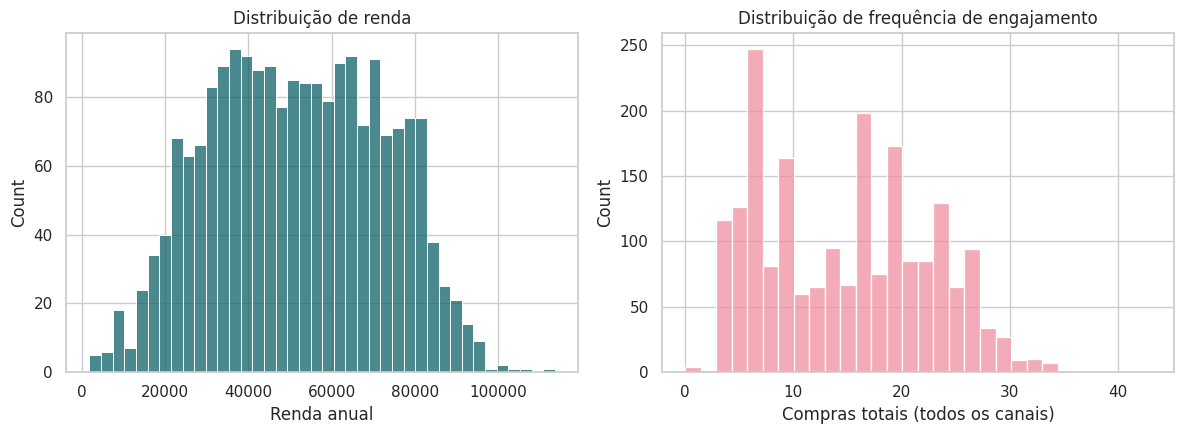

In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df_limpo.Income, bins=40, color=TEAL, ax=eixos[0])
eixos[0].set(title="Distribuição de renda", xlabel="Renda anual")
sns.histplot(df_limpo.frequencia_total, bins=30, color=CORAL, ax=eixos[1])
eixos[1].set(title="Distribuição de frequência de engajamento", xlabel="Compras totais (todos os canais)")
plt.tight_layout()
plt.show()

In [8]:
df_limpo.to_csv(DATA / "ifood_clean.csv", index=False)
print("salvo:", DATA / "ifood_clean.csv")

salvo: /home/claude/ifood-project/data/ifood_clean.csv


## Conclusão

O dataset é pequeno, 2.021 clientes depois da limpeza, mas é limpo, bem documentado e vem de uma fonte com peso: o próprio time de dados do iFood. A partir daqui, `df_limpo` e o arquivo salvo `ifood_clean.csv` formam a base usada em todos os notebooks seguintes.